In [ ]:
%pip install pandas openpyxl

In [1]:
import pandas as pd

In [23]:
spring_df = pd.read_excel("C:/Users/noaht/Downloads/228_SF Prospect Import_6.6.2025.xlsx", header=2)

In [24]:
spring_df = spring_df.drop(0)   # drops first row
spring_df.head()

,"Assigned Property Code\n\nOne Property Code and Prospect entry per line. If a prospect is associated to multiple properties, they need separate lines in the file",Legal First Name,Last Name,Gender,Email,Cell Phone,Text Message Opt In,"Anticipated Move-In Date\n\nIf not populated by prospect, use the first date (Renewal or New) of the applicable term (typically Full Term for this process).\nKeep in mind if the date is outside of the earliest start term date and latest end term date, Season of Interest will NOT populate.",Are you a student?,Floor Plan Interest\n\nIf no value provided - Enter No Preference,How did you hear about us?,In the fall of,I will be a,What best describes you?,University Attending,Method Of Contact,Prospect Status\n\nShould be set to Open,Property Interest\n\nPopulated by IT Support
1,228,Belinda,Swift,NaN,dondaxrid@hotmail.com,78651206,NaN,2025-09-19,No,No Preference,Flyer / Promo,NaN,NaN,Current Resident,University of Washington,On_Site,Open,NaN
2,228,cici,yang,NaN,zallgp@icloud.com,3213157795,NaN,2025-09-19,Yes,No Preference,On-Campus Event,NaN,NaN,Living in an off-campus apartment,University of Washington,On_Site,Open,NaN
3,228,Victoria,Plom,NaN,victoriaplom1@gmail.com,2532526412,NaN,2025-09-19,Yes,No Preference,On-Campus Event,NaN,NaN,Living in an off-campus apartment,University of Washington,On_Site,Open,NaN
4,228,Lydia,Sorbo,NaN,lesorbo@gmail.com,2069481116,NaN,2025-09-19,Yes,No Preference,Internet Search,NaN,NaN,Current Resident,University of Washington,On_Site,Open,NaN
5,228,Ashley,Wu,NaN,ashl3y.wu@gmail.com,7144086947,NaN,2025-09-19,Yes,No Preference,Instagram,NaN,NaN,Living in an off-campus apartment,University of Washington,On_Site,Open,NaN


In [11]:
# the column names are super long. I want to just select them by position instead
col_map = pd.DataFrame({
    "Index": range(len(spring_df.columns)),
    "Column Name": spring_df.columns
})

col_map

,Index,Column Name
0,0,Assigned Property Code\n\nOne Property Code an...
1,1,Legal First Name
2,2,Last Name
3,3,Gender
4,4,Email
5,5,Cell Phone
6,6,Text Message Opt In
7,7,Anticipated Move-In Date\n\nIf not populated b...
8,8,Are you a student?
9,9,Floor Plan Interest\n\nIf no value provided - ...


In [17]:
spring_df.iloc[:,[8,10,13,]] 

,Are you a student?,How did you hear about us?,What best describes you?
1,No,Flyer / Promo,Current Resident
2,Yes,On-Campus Event,Living in an off-campus apartment
3,Yes,On-Campus Event,Living in an off-campus apartment
4,Yes,Internet Search,Current Resident
5,Yes,Instagram,Living in an off-campus apartment
...,...,...,...
1970,Yes,Word of Mouth,An Incoming Freshman
1971,Yes,Sporting Event,Living at Another ACC Community
1972,Yes,Flyer / Promo,Living in an off-campus apartment
1973,Yes,On-Campus Event,Living on Campus


In [16]:
spring_df.iloc[:,9].unique()    # I'm not going to look at this column then

<StringArray>
['No Preference']
Length: 1, dtype: str

In [18]:
import matplotlib.pyplot as plt

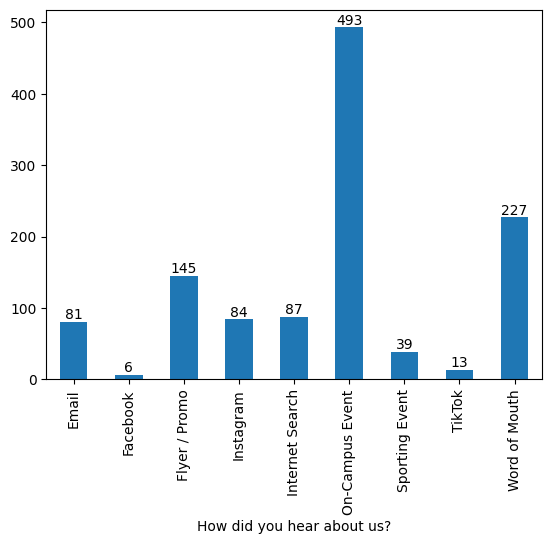

In [32]:
# filtering to just the column I want
spring_filtered = spring_df[spring_df.iloc[:,8] == "Yes"]

# grouping the column
result = spring_filtered.groupby(
    spring_filtered.iloc[:,10]
).size()

# plot
ax = result.plot(
    kind="bar")
# show the count values above the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
spring_filtered = spring_df[spring_df.iloc[:, 8] == "Yes"]

pivot = spring_filtered.pivot_table(
    index=spring_filtered.columns[2],   # x-axis categories
    columns=spring_filtered.columns[3], # split into side-by-side bars
    values=spring_filtered.columns[5],  # y-axis values
    aggfunc="sum"
)

pivot.plot(kind="bar")

plt.show()